# Churn Classification — Baseline Models

This notebook plugs directly into the production pipeline (MySQL → `feature_engineering.py`) and compares four baseline classifiers:

| Model | Role |
|---|---|
| `DummyClassifier` | Floor — any real model must beat this |
| `LogisticRegression` | Interpretable linear baseline |
| `RandomForestClassifier` | Non-linear ensemble baseline |
| `LGBMClassifier` | Gradient boosting baseline |

Mirrors the data loading pattern of `model_experiment.ipynb`.

## Section 1 — Imports & Setup

In [14]:
%load_ext autoreload
%autoreload 2

import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory so we can import feature_engineering and data modules
sys.path.append(os.path.abspath(os.path.join('..')))

from feature_engineering import CustomerFeatureEngineer
from data.ingestion_pipeline import get_mysql_engine

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

from lightgbm import LGBMClassifier

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Section 2 — Load Data from Pipeline

Identical pattern to `model_experiment.ipynb`:
1. Run `feature_engineering.py` to compute RFM, rolling, and behavioral features from `raw_transactions`
2. Pull `customer_data` for the churn label and demographics
3. Merge on `customer_id`

In [15]:
# 1. Run feature engineering against MySQL raw_transactions
engineer = CustomerFeatureEngineer()
behavioral_features = engineer.run_feature_engineering()

# 2. Pull customer master table (churn label + demographics)
engine = get_mysql_engine()
customer_df = pd.read_sql_query("""
    SELECT customer_id, age, gender, city, segment_initial, tenure_months, churn
    FROM customer_data
""", engine)

# 3. Merge
df = pd.merge(customer_df, behavioral_features, on='customer_id', how='inner')

print(f"Merged shape: {df.shape}")
print(f"Churn rate: {df['churn'].mean():.2%}")
df.head()

INFO:data.ingestion_pipeline:MySQL engine created successfully (pooled)
INFO:feature_engineering:Loaded 80,000 transactions for 5,000 customers
INFO:data.ingestion_pipeline:MySQL engine created successfully (pooled)
INFO:feature_engineering:Feature engineering completed. Shape: (5000, 37)
INFO:data.ingestion_pipeline:MySQL engine created successfully (pooled)


Merged shape: (5000, 43)
Churn rate: 13.36%


,customer_id,age,gender,city,segment_initial,tenure_months,churn,recency_days,frequency,monetary_value,...,transaction_count_total,active_days,active_days_ratio,received_promotion,num_promotions,promotion_types,last_promotion_date,days_since_last_promotion,snapshot_date,feature_version
0,CUST000000,28,Male,TP.HCM,Mass,29,0,229,16,166982.06,...,16,16,0.941176,0,0,[None],NaT,999.0,2026-04-24 19:46:29.492053,20260424_1946
1,CUST000001,47,Female,Hải Phòng,Mass,29,0,215,19,208095.02,...,19,19,0.950000,0,0,[None],NaT,999.0,2026-04-24 19:46:29.492053,20260424_1946
2,CUST000002,25,Male,Hà Nội,Mass,23,0,263,6,62411.65,...,6,6,0.857143,0,0,[None],NaT,999.0,2026-04-24 19:46:29.492053,20260424_1946
3,CUST000003,45,Female,TP.HCM,Mass,26,0,276,18,205728.75,...,18,18,0.947368,0,0,[None],NaT,999.0,2026-04-24 19:46:29.492053,20260424_1946
4,CUST000004,26,Male,TP.HCM,Mass,37,0,276,14,140000.00,...,14,14,0.933333,1,1,[Fee waiver],2022-01-01 21:02:50.674134826,1573.0,2026-04-24 19:46:29.492053,20260424_1946


> **Data Quality Note**
>
> The `churn` label in `customer_data` is currently assigned by a simple demographic rule in `data/generate_bank_data.py`:
> ```python
> high_risk = (tenure_months < 6) | (age < 25)
> churn = random.choice([0, 1], p=[0.3, 0.7])  # for high_risk customers only
> ```
> Transactions are randomly scattered across all customers with **no link to the churn label**, so transaction-derived features (RFM, rolling windows, behavioral stats) carry weak predictive signal for this label. Expect modest AUC scores — this is a **data generation issue**, not a modeling issue. Fix: rewrite `generate_bank_data.py` to use a Poisson decay simulation (as in `lab/Churn_Classification.ipynb`) and derive churn from behavior via a cutoff window.

## Section 3 — Preprocessing

Reuses the same logic as `model_experiment.ipynb` cell 3, extended for classification.

In [16]:
df_model = df.copy()

# 1. Drop ID / metadata columns
columns_to_drop = [
    'customer_id', 'tenant_id', 'snapshot_date', 'feature_version',
    'first_tx', 'last_tx', 'promotion_types'
]
df_model = df_model.drop(columns=[c for c in columns_to_drop if c in df_model.columns])

# 2. Drop highly correlated columns (prevents ConvergenceError in LogReg)
correlated_cols = [
    'T',                       # duplicated by T_months
    'recency_days',            # duplicated by recency_months
    'transaction_count_total', # highly correlated with frequency
    'active_days',             # highly correlated with active_days_ratio
]
df_model = df_model.drop(columns=[c for c in correlated_cols if c in df_model.columns])

# 3. One-hot encode categoricals
cols_to_encode = ['gender', 'city', 'segment_initial']
existing_cats = [c for c in cols_to_encode if c in df_model.columns]
if existing_cats:
    df_model = pd.get_dummies(df_model, columns=existing_cats, drop_first=True, dtype=float)

# 4. Strip any remaining non-numeric columns (e.g. datetime objects)
df_model = df_model.select_dtypes(include=['number'])

# 5. Drop zero-variance columns
zero_var = df_model.var()[df_model.var() < 1e-5].index.tolist()
if zero_var:
    print(f"Dropping zero-variance columns: {zero_var}")
    df_model = df_model.drop(columns=zero_var)

# 6. Separate features and target
# Note: tenure_months is kept as a FEATURE here (unlike model_experiment.ipynb
# where it is the survival duration column)
y = df_model['churn'].astype(int)
X = df_model.drop(columns=['churn'])

print(f"Feature matrix: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean():.2%}")

Dropping zero-variance columns: ['monetary_ratio', 'min_tx_value']
Feature matrix: (5000, 30)
Class distribution:
churn
0    4332
1     668
Name: count, dtype: int64
Churn rate: 13.36%


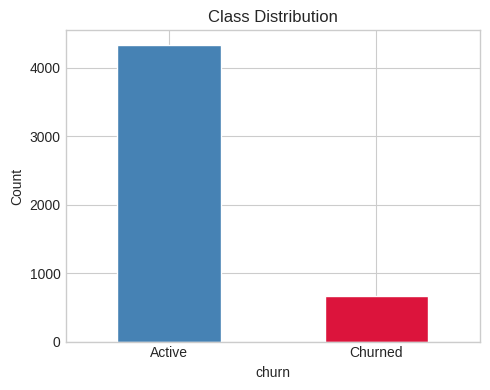

In [17]:
# Visualise class imbalance
fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().rename({0: 'Active', 1: 'Churned'}).plot(
    kind='bar', ax=ax, color=['steelblue', 'crimson'], edgecolor='white'
)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
ax.set_xticklabels(['Active', 'Churned'], rotation=0)
plt.tight_layout()
plt.show()

## Section 4 — Stratified Train / Test Split

`stratify=y` ensures both splits preserve the same churn ratio — essential at low churn rates (~12%).

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} rows  |  churn rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape[0]:,} rows  |  churn rate: {y_test.mean():.2%}")

Train: 3,500 rows  |  churn rate: 13.37%
Test:  1,500 rows  |  churn rate: 13.33%


## Section 5 — Train All Baseline Models

Each model handles class imbalance explicitly:
- `DummyClassifier`: stratified random — establishes the floor
- `LogisticRegression`: wrapped in a `Pipeline` with `StandardScaler` (required for convergence); `class_weight='balanced'`
- `RandomForestClassifier`: `class_weight='balanced'`
- `LGBMClassifier`: explicit `class_weight={0:1, 1:5}` (5× penalty for missing a churner)

In [19]:
models = {
    "Dummy": DummyClassifier(
        strategy="stratified",
        random_state=RANDOM_STATE
    ),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        class_weight={0: 1, 1: 5},
        random_state=RANDOM_STATE,
        verbose=-1
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")

Trained: Dummy
Trained: Logistic Regression
Trained: Random Forest
Trained: LightGBM


## Section 6 — Evaluation Table

Three complementary metrics:
- **AUC-ROC**: overall ranking quality
- **PR-AUC**: performance on the minority (churned) class — more informative at low churn rates
- **Brier Score**: calibration quality (lower is better; 0 = perfect)

In [20]:
def evaluate(name, model, X, y):
    proba = model.predict_proba(X)[:, 1]
    return {
        "Model": name,
        "AUC-ROC": round(roc_auc_score(y, proba), 4),
        "PR-AUC":  round(average_precision_score(y, proba), 4),
        "Brier":   round(brier_score_loss(y, proba), 4),
    }

results = pd.DataFrame([
    evaluate(name, model, X_test, y_test)
    for name, model in models.items()
])

results = results.sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
results

,Model,AUC-ROC,PR-AUC,Brier
0,LightGBM,0.9615,0.6594,0.0566
1,Random Forest,0.9557,0.6206,0.0536
2,Logistic Regression,0.8567,0.4792,0.1520
3,Dummy,0.4788,0.1297,0.2507


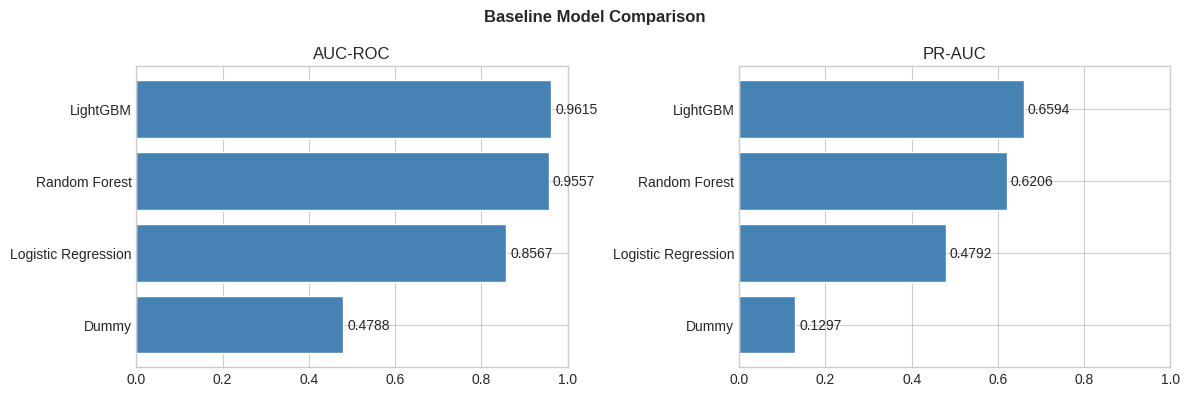

In [21]:
# Bar chart comparison
metrics = ["AUC-ROC", "PR-AUC"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, metrics):
    sorted_df = results.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df["Model"], sorted_df[metric], color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.set_title(metric)
    ax.set_xlim(0, 1)

plt.suptitle("Baseline Model Comparison", fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7 — Feature Importance

Shows which engineered features (RFM, rolling windows, behavioral statistics) are picked up by RF and LightGBM.

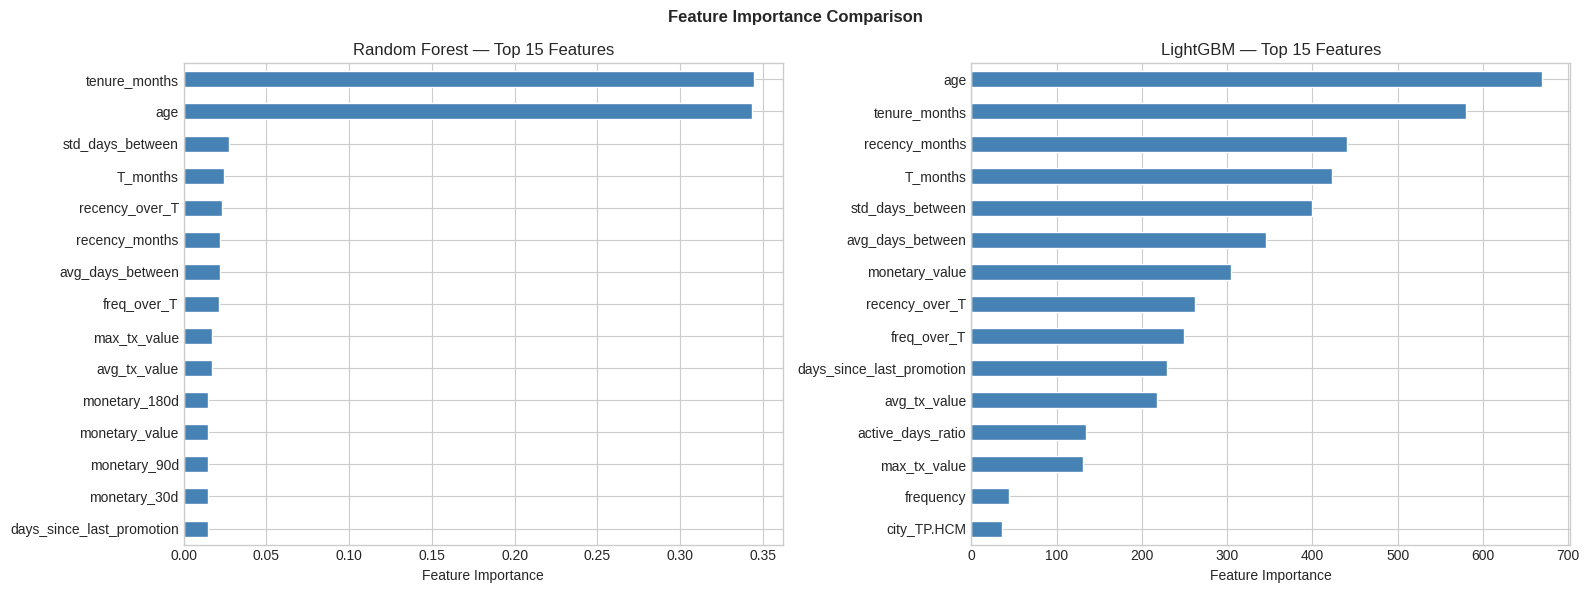

In [22]:
rf_model = models["Random Forest"]
lgbm_model = models["LightGBM"]

rf_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
lgbm_imp = pd.Series(lgbm_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, imp, title in zip(axes, [rf_imp, lgbm_imp], ["Random Forest", "LightGBM"]):
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f"{title} — Top 15 Features")
    ax.set_xlabel("Feature Importance")

plt.suptitle("Feature Importance Comparison", fontweight='bold')
plt.tight_layout()
plt.show()

## Section 8 — Calibration Curves

Calibration measures whether predicted probabilities match actual churn rates.
Well-calibrated models are essential because `churn_probability` will eventually be stored in the `customer_features` table and used for business decisions (e.g. trigger a retention campaign at p > 0.40).

A perfectly calibrated model lies on the diagonal. Points above = overestimates churn; below = underestimates.

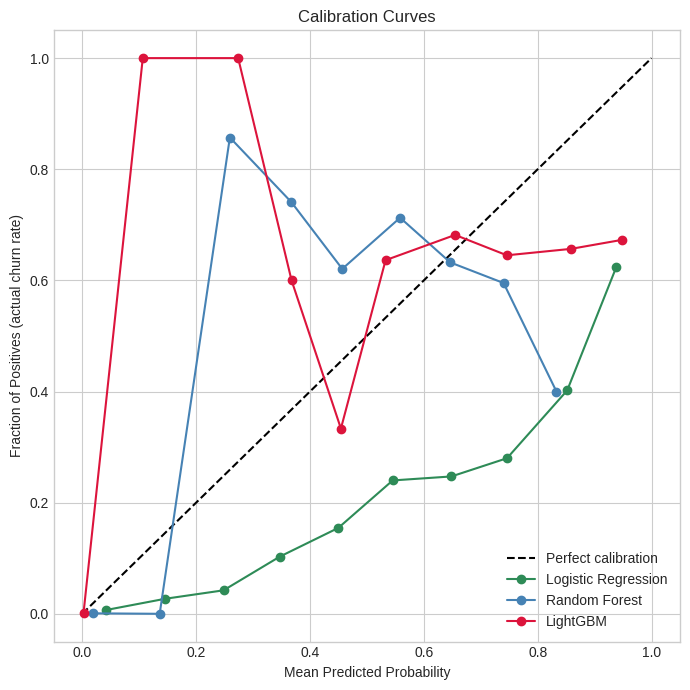

In [23]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

colors = {'Random Forest': 'steelblue', 'LightGBM': 'crimson', 'Logistic Regression': 'seagreen'}

for name in ['Logistic Regression', 'Random Forest', 'LightGBM']:
    proba = models[name].predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', label=name, color=colors[name])

ax.set_title('Calibration Curves')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (actual churn rate)')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Model | Expected behaviour on this data |
|---|---|
| Dummy | AUC ≈ 0.50 — random |
| Logistic Regression | Slightly above Dummy; only age/tenure are truly predictive |
| Random Forest | Similar range — limited by label quality, not model capacity |
| LightGBM | Likely best AUC but still modest — same label quality constraint |

**Next step**: Fix `data/generate_bank_data.py` to use a Poisson decay simulation (churners' transaction activity declines in their final 90 days) and derive the churn label from a behavioral cutoff window rather than demographics. Re-run this notebook on the improved data to get meaningful benchmark numbers.